In [1]:
import torch

In [2]:
def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)

    return z

In [3]:
print(f'Scalar Inputs: {compute_z(torch.tensor(1), torch.tensor(2), torch.tensor(3))}')

print(f'Rank 1 Inputs: {compute_z(torch.tensor([1]), torch.tensor([2]), torch.tensor([3]))}')

print(f'Rank 2 Inputs: {compute_z(torch.tensor([[1]]), torch.tensor([[2]]), torch.tensor([[3]]))}')

Scalar Inputs: 1
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


In [4]:
import torch.nn as nn 
torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


In [5]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)

model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, '$x_2$')

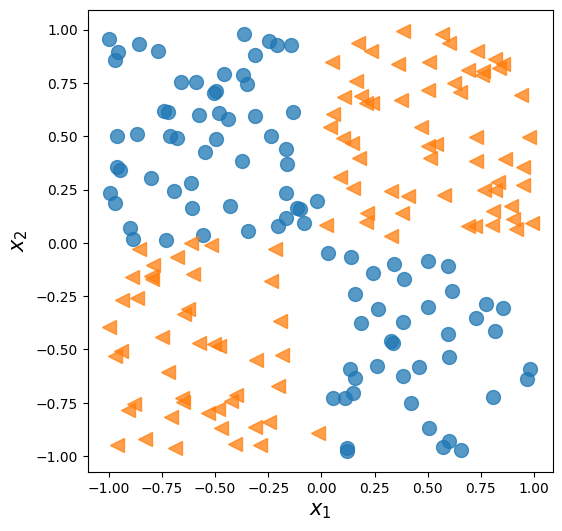

In [7]:
torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))

y[x[:, 0] * x[:, 1] < 0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)


In [8]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

In [9]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


In [10]:
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [11]:
torch.manual_seed(1)
num_epochs = 200

def train(model, num_epochs, train_dl, x_valid, y_valid):

    loss_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs

    for epoch in range(num_epochs):

        model.train()
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        n_examples = 0

        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_len = y_batch.size(0)
            train_loss_sum += loss.item() * batch_len
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            train_acc_sum += is_correct.sum().item()
            n_examples += batch_len

        loss_hist_train[epoch] = train_loss_sum / n_examples
        accuracy_hist_train[epoch] = train_acc_sum / n_examples

        model.eval()
        with torch.no_grad():
            pred = model(x_valid)[:, 0]
            loss = loss_fn(pred, y_valid)
            loss_hist_valid[epoch] = loss.item()
            is_correct = ((pred >= 0.5).float() == y_valid).float()
            accuracy_hist_valid[epoch] = is_correct.mean().item()

    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [12]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

Text(0.5, 0, 'Epochs')

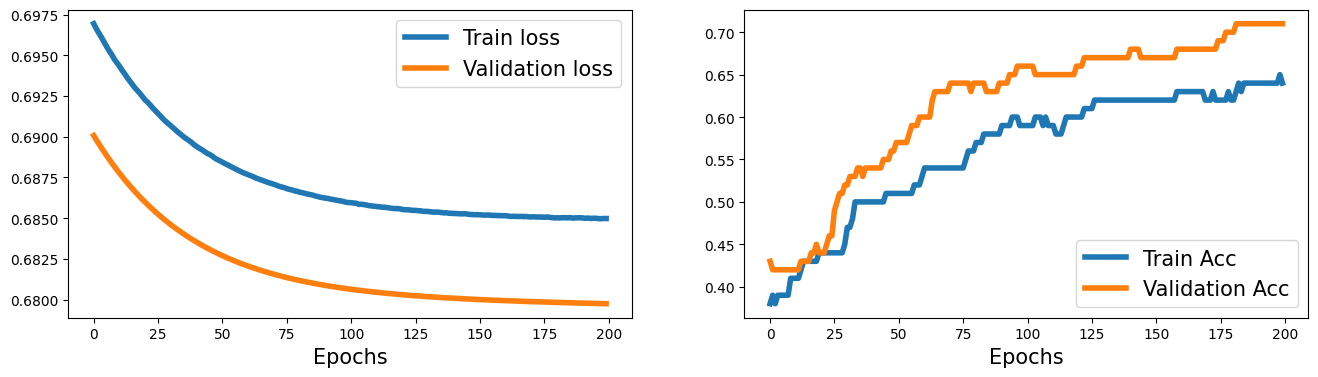

In [13]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train Acc', 'Validation Acc'], fontsize=15)
ax.set_xlabel('Epochs', size=15)



In [14]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

model

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)

Text(0.5, 0, 'Epochs')

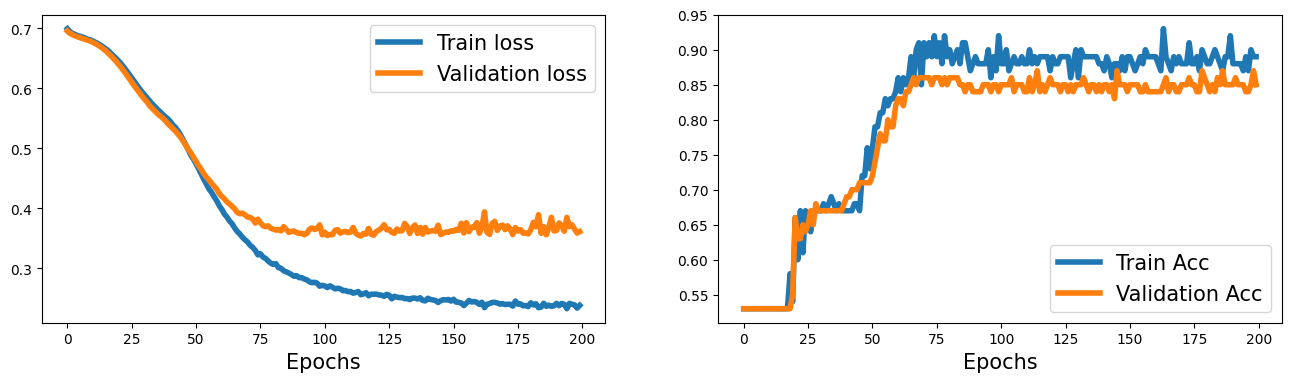

In [15]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train Acc', 'Validation Acc'], fontsize=15)
ax.set_xlabel('Epochs', size=15)



In [16]:
class MyModule(nn.Module):

    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()

        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)


    def forward(self, x):
        for f in self.module_list:
            x = f(x)

        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()

In [17]:
model = MyModule()
model

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [18]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

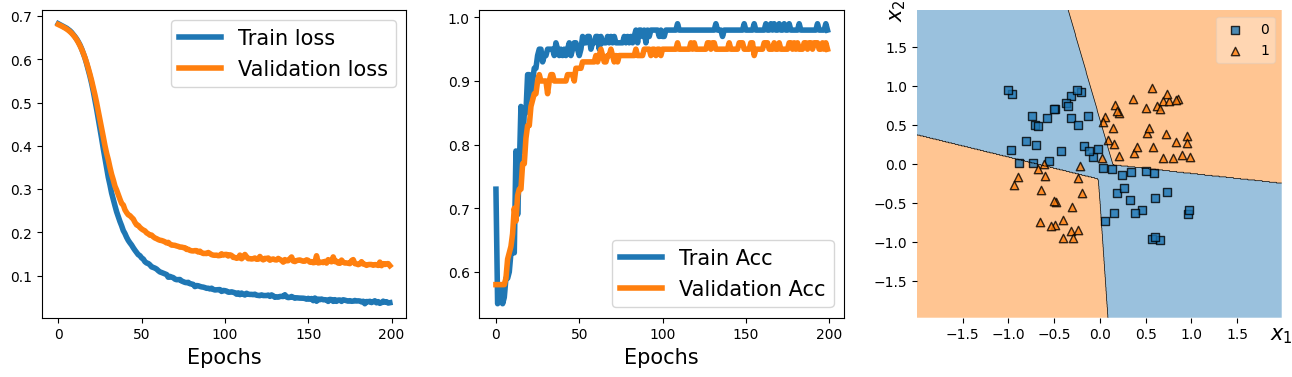

In [19]:
from mlxtend.plotting import plot_decision_regions

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train Acc', 'Validation Acc'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(
    X=x_valid.numpy(),
    y=y_valid.numpy().astype(np.int_),
    clf=model 
)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()


In [20]:
class NoisyLayer(nn.Module):

    def __init__(self, input_size, output_size, noise_stddev=0.1):

        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)
        nn.init.xavier_uniform_(w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)

        else:
            x_new = x

        return torch.add(torch.mm(x_new, self.w), self.b)

In [21]:
torch.manual_seed(1)
noisy_layer = NoisyLayer(4, 2)
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=False))



tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


In [22]:
class MyNoisyModule(nn.Module):

    def __init__(self):
        super().__init__()
        self.l1 = NoisyLayer(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()

    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)

        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)

        pred = self.forward(x)[:, 0]
        return (pred >= 0.5).float()


torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLayer()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

In [23]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)

history = train(model, num_epochs, train_dl, x_valid, y_valid)

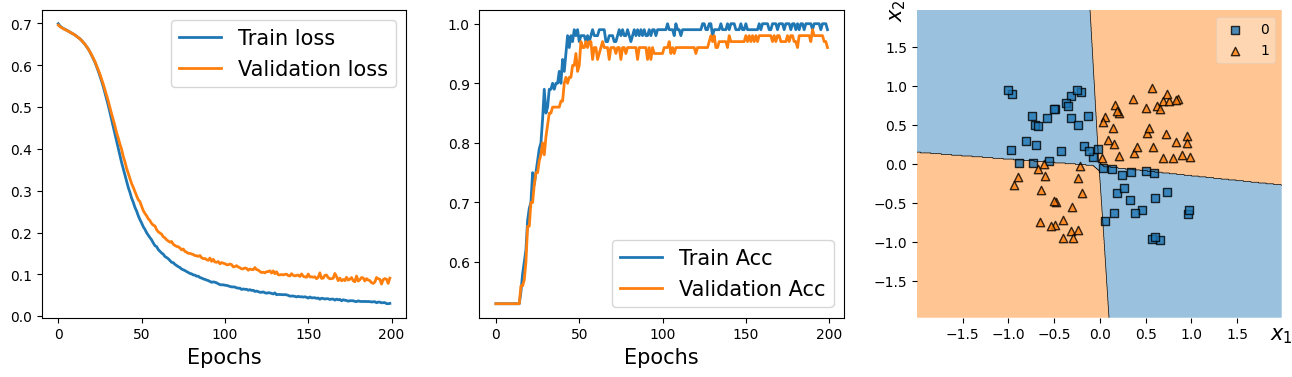

In [24]:

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=2)
plt.plot(history[1], lw=2)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=2)
plt.plot(history[3], lw=2)
plt.legend(['Train Acc', 'Validation Acc'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(
    X=x_valid.numpy(),
    y=y_valid.numpy().astype(np.int_),
    clf=model 
)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()


In [25]:
import pandas as pd 


In [26]:
url = ('http://archive.ics.uci.edu/ml/' 
       'machine-learning-databases/auto-mpg/auto-mpg.data'
       )
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower',
                'Weight', 'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv(url, names=column_names,
                 na_values='?', comment='\t',
                 sep=' ', skipinitialspace=True)

df = df.dropna()
df.reset_index(inplace=True, drop=True)

In [27]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size=0.8, random_state=1)

In [28]:
train_stats = df_train.describe().transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
MPG,313.0,23.404153,7.666909,9.0,17.5,23.0,29.0,46.6
Cylinders,313.0,5.402556,1.701506,3.0,4.0,4.0,8.0,8.0
Displacement,313.0,189.512780,102.675646,68.0,104.0,140.0,260.0,455.0
Horsepower,313.0,102.929712,37.919046,46.0,75.0,92.0,120.0,230.0
Weight,313.0,2961.198083,848.602146,1613.0,2219.0,2755.0,3574.0,5140.0
Acceleration,313.0,15.704473,2.725399,8.5,14.0,15.5,17.3,24.8
Model Year,313.0,75.929712,3.675305,70.0,73.0,76.0,79.0,82.0
Origin,313.0,1.591054,0.807923,1.0,1.0,1.0,2.0,3.0


In [29]:
numeric_column_names = ['Cylinders', 'Displacement', 'Horsepower', 
                        'Weight', 'Acceleration']
df_train_norm, df_test_norm = df_train.copy(), df_test.copy()

for col in numeric_column_names:

    mean = train_stats.loc[col, 'mean']
    std = train_stats.loc[col, 'std']

    df_train_norm[col] = (df_train_norm.loc[:, col] - mean)/std
    df_test_norm[col] = (df_test_norm.loc[:, col] - mean)/std

df_train_norm.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
203,28.0,-0.824303,-0.901020,-0.736562,-0.950031,0.255202,76,3
255,19.4,0.351127,0.413800,-0.340982,0.293190,0.548737,78,1
72,13.0,1.526556,1.144256,0.713897,1.339617,-0.625403,72,1
235,30.5,-0.824303,-0.891280,-1.053025,-1.072585,0.475353,77,1
37,14.0,1.526556,1.563051,1.636916,1.470420,-1.359240,71,1


In [30]:
boundaries = torch.tensor([73, 76, 779])
v = torch.tensor(df_train_norm['Model Year'].values)
df_train_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)

v = torch.tensor(df_test_norm['Model Year'].values)
df_test_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)

numeric_column_names.append('Model Year Bucketed')


In [31]:
df_test_norm.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Model Year Bucketed
23,26.0,-0.824303,-0.667274,0.265573,-0.856936,-1.175781,70,2,0
293,35.7,-0.824303,-0.891280,-0.604702,-1.232849,-0.478636,79,1,2
13,14.0,1.526556,2.585688,3.219234,0.147068,-2.093078,70,1,0
90,13.0,1.526556,2.050021,1.241336,1.770915,-1.359240,73,1,1
61,13.0,1.526556,1.563051,1.636916,1.547017,-1.359240,72,1,0


In [32]:
from torch.nn.functional import one_hot
total_origin = len(set(df_train_norm['Origin']))
print(total_origin)
origin_encoded = one_hot(torch.from_numpy(df_train_norm['Origin'].values) % total_origin)

x_train_numeric = torch.tensor(df_train_norm[numeric_column_names].values)

x_train = torch.cat([x_train_numeric, origin_encoded], 1).float()

origin_encoded = one_hot(torch.from_numpy(df_test_norm['Origin'].values) % total_origin)

x_test_numeric = torch.tensor(df_test_norm[numeric_column_names].values)

x_test = torch.cat([x_test_numeric, origin_encoded], 1).float()

3


/var/folders/zt/f_lrs0nx2jn33c6pmdxrlwpc0000gn/T/ipykernel_15902/3650603287.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  origin_encoded = one_hot(torch.from_numpy(df_train_norm['Origin'].values) % total_origin)


In [33]:
y_train = torch.tensor(df_train_norm['MPG'].values).float()
y_test = torch.tensor(df_test_norm['MPG'].values).float()

In [34]:
train_ds = TensorDataset(x_train, y_train)
batch_size = 8
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)


In [35]:
hidden_units = [8, 4]
input_size = x_train.shape[1]

all_layers = []

for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit

all_layers.append(nn.Linear(hidden_units[-1], 1))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Linear(in_features=9, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

In [36]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
torch.manual_seed(1)
num_epochs = 200
log_epochs = 20

In [37]:
for epoch in range(num_epochs):
    loss_hist_train = 0
    for x_batch, y_batch in train_dl:
        model.train()
        pred = model(x_batch)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train += loss.item()

    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss '
              f'{loss_hist_train/len(train_dl):.4f}')


Epoch 0 Loss 543.0531
Epoch 20 Loss 10.5772
Epoch 40 Loss 10.2568
Epoch 60 Loss 10.0934
Epoch 80 Loss 9.6148
Epoch 100 Loss 9.4840
Epoch 120 Loss 9.4857
Epoch 140 Loss 9.1349
Epoch 160 Loss 9.4425
Epoch 180 Loss 9.8034


In [38]:
with torch.no_grad():
    model.eval()
    pred = model(x_test.float())[:, 0]
    loss = loss_fn(pred, y_test)
    print(f'Test MSE: {loss.item():.4f}')
    print(f'Test MAE: {nn.L1Loss()(pred, y_test):.4f}')

Test MSE: 14.6531
Test MAE: 2.4831


In [39]:
import torchvision
from torchvision import transforms



In [40]:
image_path = './'
transform = transforms.Compose(
    [transforms.ToTensor()]
)

mnist_train_dataset = torchvision.datasets.MNIST(image_path, train=True, transform=transform, download=True)
mnist_test_dataset = torchvision.datasets.MNIST(image_path, train=False, transform=transform, download=True)

train_dl = DataLoader(mnist_test_dataset, batch_size=64, shuffle=True)

In [41]:
hidden_units = [32, 16]
image_size = mnist_train_dataset[0][0].shape
input_size = image_size[0] * image_size[1] * image_size[2]
all_layers = [nn.Flatten()]

for h in hidden_units:
    layer = nn.Linear(input_size, h)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = h

all_layers.append(nn.Linear(hidden_units[-1], 10))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)

In [42]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20


In [43]:
for epoch in range(num_epochs):

    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:

        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (
            torch.argmax(pred, axis=1) == y_batch
        ).float()

        accuracy_hist_train += is_correct.sum()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch} Accuracy '
          f'{accuracy_hist_train:.4f}')

Epoch 0 Accuracy 0.6486
Epoch 1 Accuracy 0.8758
Epoch 2 Accuracy 0.9021
Epoch 3 Accuracy 0.9164
Epoch 4 Accuracy 0.9265
Epoch 5 Accuracy 0.9309
Epoch 6 Accuracy 0.9397
Epoch 7 Accuracy 0.9427
Epoch 8 Accuracy 0.9457
Epoch 9 Accuracy 0.9480
Epoch 10 Accuracy 0.9515
Epoch 11 Accuracy 0.9566
Epoch 12 Accuracy 0.9578
Epoch 13 Accuracy 0.9619
Epoch 14 Accuracy 0.9633
Epoch 15 Accuracy 0.9672
Epoch 16 Accuracy 0.9723
Epoch 17 Accuracy 0.9711
Epoch 18 Accuracy 0.9736
Epoch 19 Accuracy 0.9767


In [44]:
pred = model(mnist_test_dataset.data/255.)

is_correct = (
    torch.argmax(pred, axis=1) == mnist_test_dataset.targets
).float()

print(f'Test Accuracy: {is_correct.mean():.4f}')






Test Accuracy: 0.9821


In [45]:
import pytorch_lightning as pl 
import torch
import torch.nn as nn
from torchmetrics import Accuracy

In [46]:

class MultilayerPerceptron(pl.LightningModule):

    def __init__(self, image_shape=(1, 28, 28), hidden_units=(32, 16)):
        super().__init__()

        self.train_acc = Accuracy(task='multiclass', num_classes=10)
        self.valid_acc = Accuracy(task='multiclass', num_classes=10)
        self.test_acc = Accuracy(task='multiclass', num_classes=10)

        input_size = image_shape[0] * image_shape[1] * image_shape[2]

        all_layers = [nn.Flatten()]
        for hidden_unit in hidden_units:

            layer = nn.Linear(input_size, hidden_unit)
            all_layers.append(layer)
            all_layers.append(nn.ReLU())
            input_size = hidden_unit


        all_layers.append(nn.Linear(hidden_units[-1], 10))
        self.model = nn.Sequential(*all_layers)

    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):

        x, y = batch
        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc.update(preds, y)
        self.log('train loss', loss, prog_bar=True)
        return loss
    
    def on_train_epoch_end(self):
        self.log('train acc', self.train_acc.compute())

    def validation_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)
        preds = torch.argmax(logits, dim=1)
        self.valid_acc.update(preds, y)
        self.log('valid loss', loss, prog_bar=True)
        self.log('valid acc', self.valid_acc.compute(), prog_bar=True)
        return loss
    
    
    def test_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)
        loss = nn.functional.cross_entropy(self(x), y)
        preds = torch.argmax(logits, dim=1)
        self.test_acc.update(preds, y)
        self.log('test loss', loss, prog_bar=True)
        self.log('test acc', self.test_acc.compute(), prog_bar=True)
        return loss
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer
    
     
        

In [47]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision.datasets import MNIST
from torchvision import transforms

In [48]:
class MnistDataModule(pl.LightningDataModule):

    def __init__(self, data_path='./'):

        super().__init__()
        self.data_path = data_path
        self.transform = transforms.Compose([transforms.ToTensor()])

    def prepare_data(self):
        MNIST(root=self.data_path, download=True)

    def setup(self, stage=None):

        mnist_all = MNIST(
            root=self.data_path,
            train=True,
            transform=self.transform,
            download=False
        )

        self.train, self.val = random_split(
            mnist_all, [55000, 5000],
            generator=torch.Generator().manual_seed(1)
        )

        self.test = MNIST(
            root=self.data_path,
            train=False,
            transform=self.transform,
            download=False
        )
    
    def train_dataloader(self):
        return DataLoader(self.train, batch_size=64, num_workers=4, persistent_workers=True)
    
    def val_dataloader(self):
        return DataLoader(self.val, batch_size=64, num_workers=4, persistent_workers=True)
    
    def test_dataloader(self):
        return DataLoader(self.test, batch_size=64, num_workers=4, persistent_workers=True)
    
        

In [49]:
torch.manual_seed(1)
mnist_dm = MnistDataModule()

In [50]:

mnistclassifier = MultilayerPerceptron()

if torch.cuda.is_available():
    trainer = pl.Trainer(max_epochs=10, gpus=1)
else:
    trainer = pl.Trainer(max_epochs=10)



GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [51]:
trainer.fit(model=mnistclassifier, datamodule=mnist_dm)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ model     │ Sequential         │ 25.8 K │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 25.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/blaiseforgwa/projects/pyml-book/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21
: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


In [52]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs/

In [53]:
ckpt_path = 'lightning_logs/version_4/checkpoints/epoch=9-step=8600.ckpt'

if torch.cuda.is_available():
    trainer = pl.Trainer(max_epochs=15, accelerator='gpu', devices=1)
else:
    trainer = pl.Trainer(max_epochs=15)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [54]:
trainer.fit(model=mnistclassifier, datamodule=mnist_dm, ckpt_path=ckpt_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at lightning_logs/version_4/checkpoints/epoch=9-step=8600.ckpt
/Users/blaiseforgwa/projects/pyml-book/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:566: The dirpath has changed from '/Users/blaiseforgwa/projects/pyml-book/ch12-pytorch-deeper/lightning_logs/version_4/checkpoints' to '/Users/blaiseforgwa/projects/pyml-book/ch12-pytorch-deeper/lightning_logs/version_7/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ model     │ Sequential         │ 25.8 K │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 25.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at lightning_logs/version_4/checkpoints/epoch=9-step=8600.ckpt


Output()

/Users/blaiseforgwa/projects/pyml-book/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21
: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=15` reached.


In [55]:
trainer.test(model=mnistclassifier, datamodule=mnist_dm)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test acc          │    0.9519428014755249     │
│         test loss         │    0.14508593082427979    │
└───────────────────────────┴───────────────────────────┘

[{'test loss': 0.14508593082427979, 'test acc': 0.9519428014755249}]